In [1]:
import pandas as pd
originaldf = pd.read_csv('sales_clean.csv')
df = originaldf

In [2]:
df.shape

(292, 6)

In [3]:
df.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.360,4,60614
1,1057,2026-05-30,charger,14.790,3,30303
2,1150,2026-05-06,mug,5.500,1,10001
3,1066,2026-05-30,notebook,6.518,1,98101
4,1114,2026-04-06,webcam,45.590,4,90405


In [4]:
df.describe()

,order_id,price,qty,zip
count,292.000000,292.000000,292.000000,292.000000
mean,1145.500000,57.043001,2.986301,45463.989726
std,84.437354,74.097505,1.409279,39284.386854
min,1000.000000,2.930000,1.000000,2116.000000
25%,1072.750000,10.648000,2.000000,2134.000000
50%,1145.500000,35.200000,3.000000,30303.000000
75%,1218.250000,60.692300,4.000000,90210.000000
max,1291.000000,479.290000,5.000000,98101.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 18.7 KB


In [6]:
df["zip"] = df["zip"].astype(str).str.zfill(5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 20.1 KB


In [8]:
print(df["price"].mean())
print(df["price"].median())
print(df["price"].std())

57.04300134246575
35.2
74.0975049995814


In [9]:
df.groupby("product")["price"].mean()

product
backpack       38.887500
charger        17.257500
desk lamp      23.118000
headphones     60.516400
keyboard       48.333790
monitor       229.644545
mug             7.990333
notebook        6.518074
pen set        10.525800
webcam         69.232895
Name: price, dtype: float64

<Axes: >

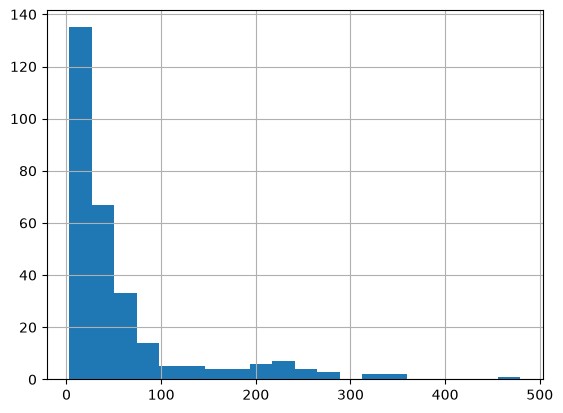

In [10]:
df["price"].hist(bins =20)

The price histogram is skewed right (tail is to the right), meaning most price values are low with the few higher price values shifting the mean to be higher than the median. 

NOTE, we do not know the quanity of each item purchased, only the price. So this histogram only shows a quantity of 1 per price per sale, regardless if more than one was purchased.

In [11]:
print(df["qty"].mean())
print(df["qty"].median())
print(df["qty"].std())

2.9863013698630136
3.0
1.4092785381929205


# Step 3 - Which of mean or median would you report for price, and why?
The price values include the prices for a variety of things (mugs to monitors). As you can see in the histogram, most of price values were low prices with only a few in the higher price range. You should use the median price since this value when the curve is skewed, the high price of a few items skews the data if the mean is used.  NOTE: The quanity of items sold is not included in this calculation. We have no way of knowing how many of each item (with the given price) were sold. 

In [12]:
df["revenue"] = df["price"] * df["qty"]

In [13]:
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.360,4,60614,45.440
1,1057,2026-05-30,charger,14.790,3,30303,44.370
2,1150,2026-05-06,mug,5.500,1,10001,5.500
3,1066,2026-05-30,notebook,6.518,1,98101,6.518
4,1114,2026-04-06,webcam,45.590,4,90405,182.360


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    str    
 6   revenue   292 non-null    float64
dtypes: float64(2), int64(2), str(3)
memory usage: 22.4 KB


In [15]:
df.corr(numeric_only=True)

,order_id,price,qty,revenue
order_id,1.000000,-0.029542,0.031420,-0.022443
price,-0.029542,1.000000,-0.053453,0.820009
qty,0.031420,-0.053453,1.000000,0.304114
revenue,-0.022443,0.820009,0.304114,1.000000


<Axes: >

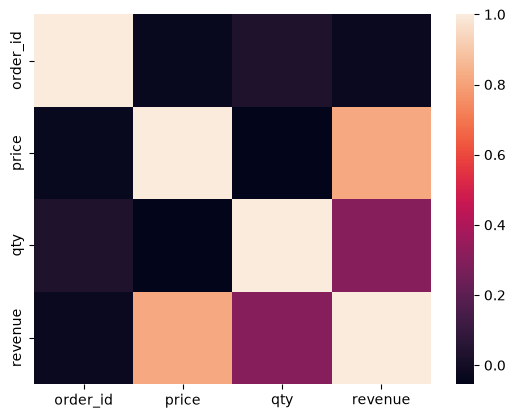

In [16]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='qty', ylabel='revenue'>

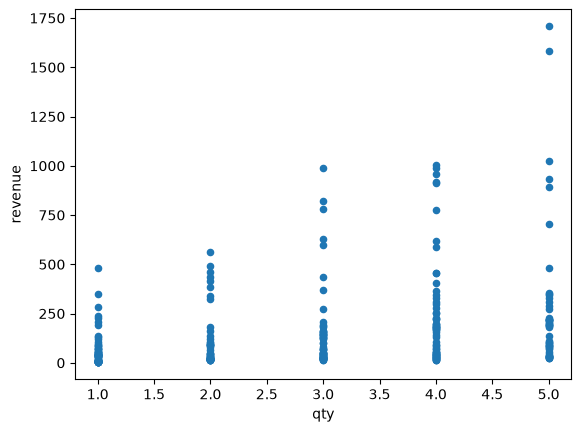

In [17]:
df.plot.scatter(x="qty", y="revenue")

Quantity vs Revenue: The scatter plot of quantity vs revenue shows that the more items purchased, the higher the revenue. When 1 item was purchased, the revenue values ranged from small dollar amounts to about 500 dollars. When 5 items were purchased, the revenue varied from small dollar amounts to about 1750 dollars. This makes sense, the more items you buy, the higher the revenue. This scatter plot looks like 5 columns because the x vales are only the integers 1 through 5. The r value for these two parameters is 0.3 indicating a moderate positive trend. The bulk of data points at the low end of the revenue would pull the linear regression to the low end (a line with a lower slope value). This would make large purchases "feel" more like outliers and decrease the r value.

<Axes: xlabel='price', ylabel='revenue'>

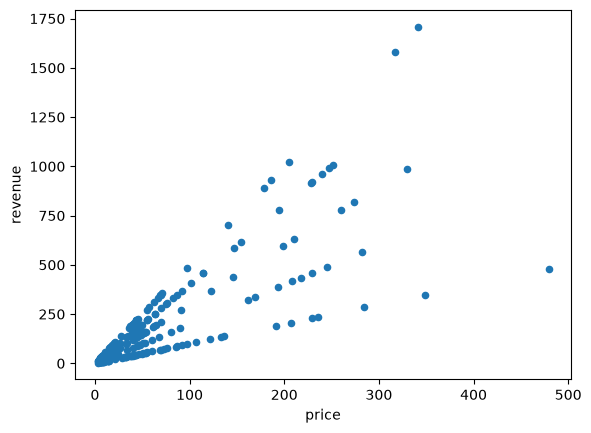

In [18]:
df.plot.scatter(x="price", y="revenue")

Price vs Revenue: The scatter plot of price vs revenue gives a quick glance at how much an item at a particular price point brought in. If we look at the data, we can see that the most expensive item (~500) only brought in 500 dollars. While the items priced at 350 dollars were purchased more often and brought in much more revenue. You can also see that the bulk of the purchased items were priced at less than 100 dollars and steadily creating a revenue less than 250 dollars at each sale. The r value for this corrrelation is 0.82. The bulk of data points at the low end of the linear regression contribute to this high correlation value.

series: [2, 4, 4, 6, 9] 

mean is 5 [(2+4+4+6+9)/5] = 25/5
median is 4 (take away the 2, 9 and the 4, 6 and 4 is left as the median value).


Used Gemini to ask how to write python code for a list of numbers and calculate the mean and median (after trying numerous times on my own).

In [19]:
import statistics

series = [2, 4, 4, 6, 9]

mean_val = statistics.mean(series)
median_val = statistics.median(series)

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")

Mean: 5
Median: 4
